In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "phase4_eda"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
hourly = pd.read_csv(
    PROCESSED_DIR / "air_quality_features.csv",
    parse_dates=['time'],
    index_col='time'
)

In [4]:
daily = pd.read_csv(
    PROCESSED_DIR / "air_quality_daily.csv",
    parse_dates=['time'],
    index_col='time'
)

In [5]:
print("Hourly:", hourly.shape)
print("Daily:", daily.shape)

print(
    "Hourly period:",
    hourly.index.min(),
    "to",
    hourly.index.max()
)

print(
    "Daily period:",
    daily.index.min(),
    "to",
    daily.index.max()
)

Hourly: (23352, 43)
Daily: (973, 30)
Hourly period: 2022-09-01 00:00:00 to 2025-04-30 23:00:00
Daily period: 2022-09-01 00:00:00 to 2025-04-30 00:00:00


In [6]:
#categorical ordering
season_order = [
    'Winter',
    'Pre-Monsoon',
    'Monsoon',
    'Post-Monsoon'
]

hourly['season'] = pd.Categorical(
    hourly['season'],
    categories=season_order,
    ordered=True
)

daily['season'] = pd.Categorical(
    daily['season'],
    categories=season_order,
    ordered=True
)

In [7]:
wind_order = [
    'N', 'NE', 'E', 'SE',
    'S', 'SW', 'W', 'NW'
]

hourly['wind_sector'] = pd.Categorical(
    hourly['wind_sector'],
    categories=wind_order,
    ordered=True
)

In [8]:
aqi_order = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

daily['particle_aqi_category'] = pd.Categorical(
    daily['particle_aqi_category'],
    categories=aqi_order,
    ordered=True
)

In [9]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [10]:
#variable group
pollutants = [
    'pm25',
    'pm10',
    'no2',
    'so2',
    'co'
]

weather_variables = [
    'temperature',
    'rain',
    'wind_speed',
    'humidity',
    'pressure',
    'dew_point'
]

## Detailed pollutant descriptive statistics

In [11]:
pollution_summary = pd.DataFrame({
    'count': hourly[pollutants].count(),
    'mean': hourly[pollutants].mean(),
    'median': hourly[pollutants].median(),
    'std': hourly[pollutants].std(),
    'min': hourly[pollutants].min(),
    'q1': hourly[pollutants].quantile(0.25),
    'q3': hourly[pollutants].quantile(0.75),
    'max': hourly[pollutants].max(),
    'skewness': hourly[pollutants].skew(),
    'kurtosis': hourly[pollutants].kurtosis()
})

pollution_summary.round(2)

,count,mean,median,std,min,q1,q3,max,skewness,kurtosis
pm25,23352,35.05,29.0,23.25,0.2,18.8,44.6,170.4,1.53,2.82
pm10,23352,48.61,42.3,28.37,0.3,27.4,64.5,221.2,1.05,1.23
no2,23352,14.27,10.6,13.57,0.0,3.7,20.7,107.3,1.66,3.69
so2,23352,6.77,5.6,4.77,0.0,3.7,8.3,37.5,2.05,5.75
co,23352,669.84,523.0,469.38,59.0,333.0,839.0,3204.0,1.69,3.05


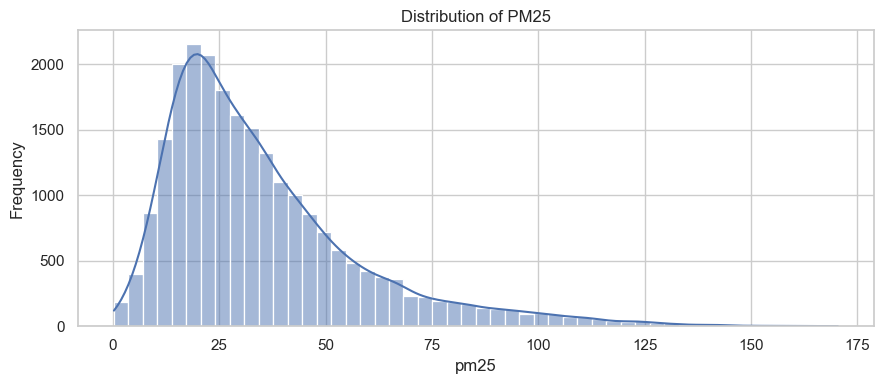

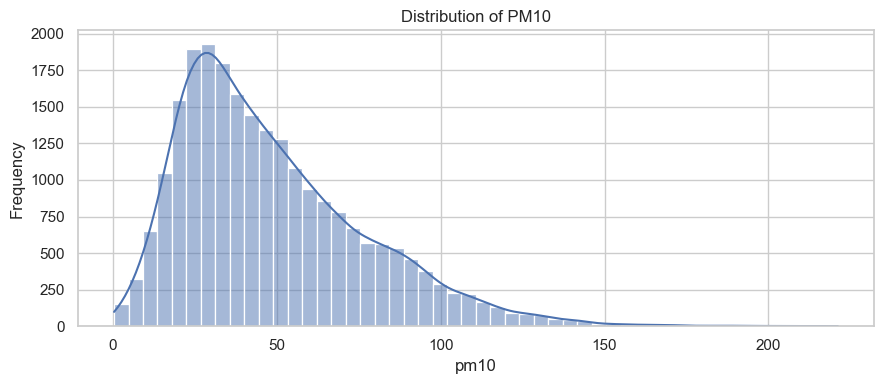

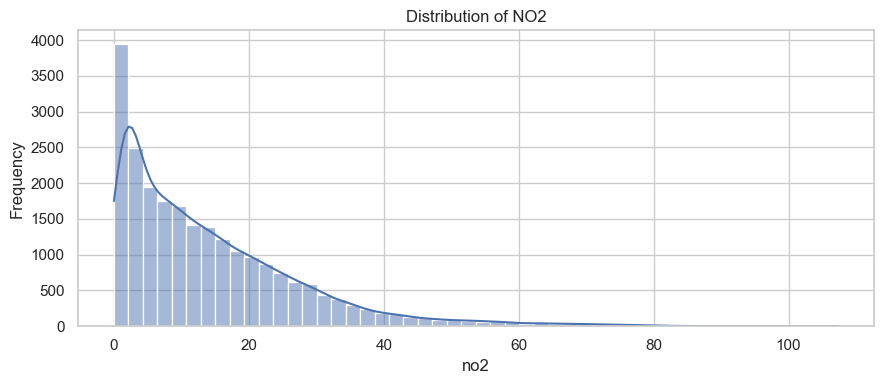

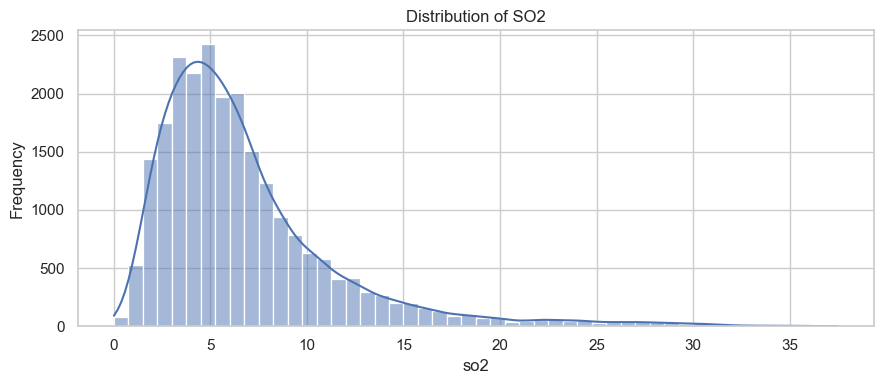

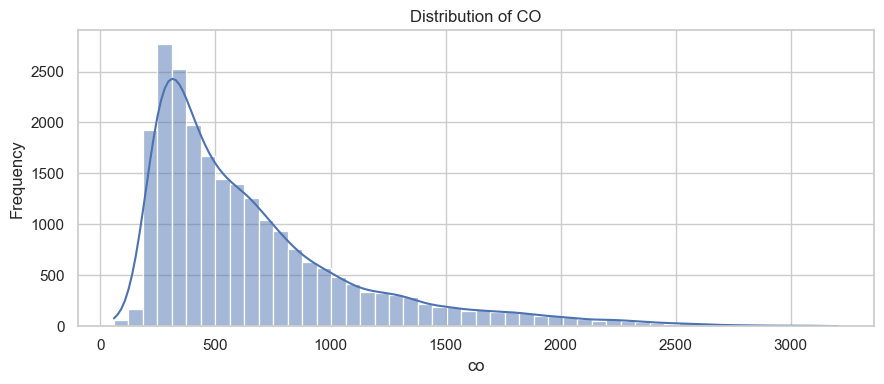

In [12]:
#pollutant distribution
for pollutant in pollutants:

    fig, ax = plt.subplots(figsize=(9, 4))

    sns.histplot(
        data=hourly,
        x=pollutant,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.set_title(
        f'Distribution of {pollutant.upper()}'
    )

    ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

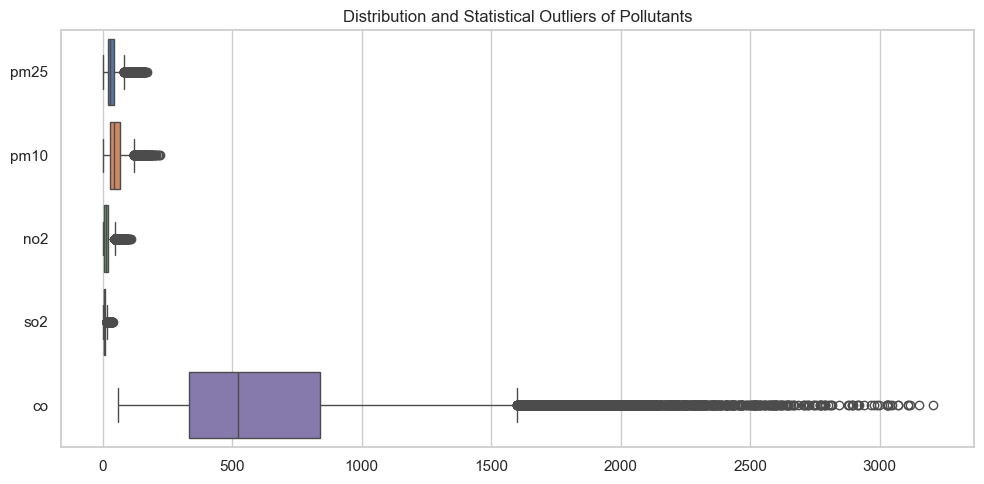

In [13]:
#Boxplots
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=hourly[pollutants],
    orient='h',
    ax=ax
)

ax.set_title(
    'Distribution and Statistical Outliers of Pollutants'
)

plt.tight_layout()
plt.show()

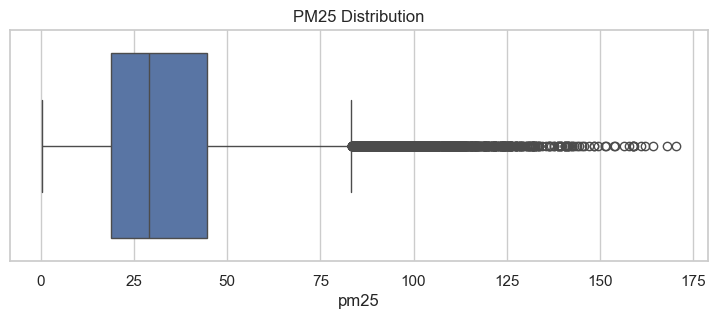

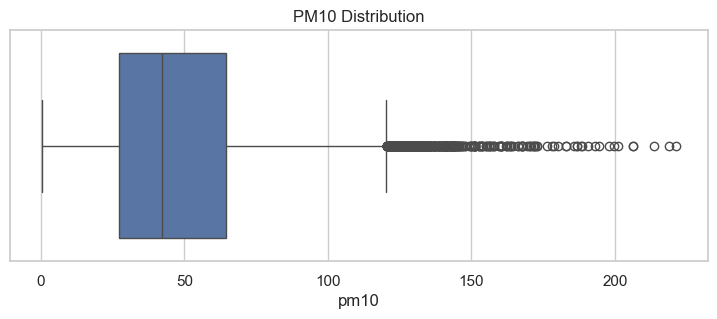

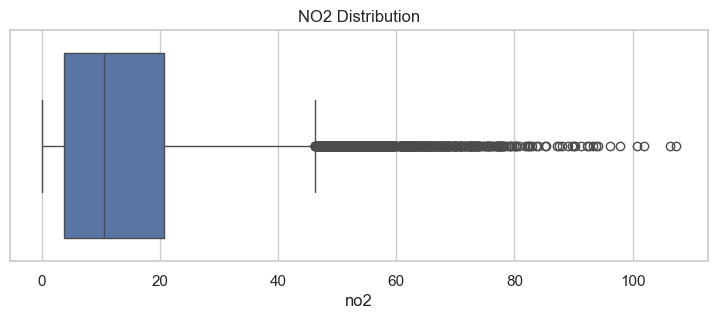

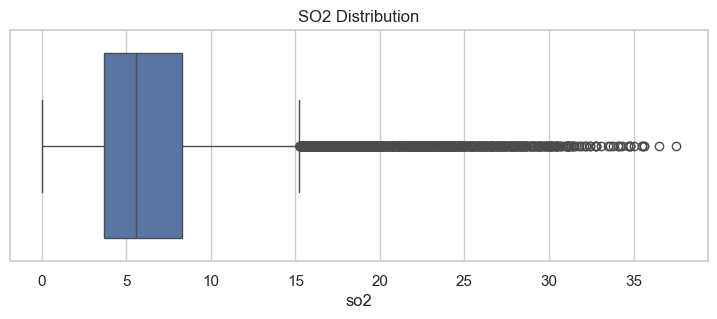

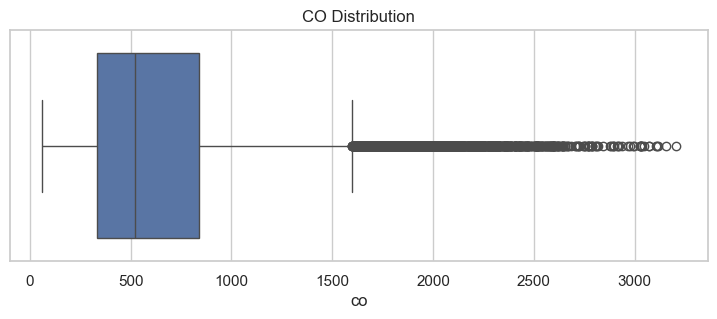

In [14]:
for pollutant in pollutants:

    plt.figure(figsize=(9, 3))

    sns.boxplot(
        x=hourly[pollutant]
    )

    plt.title(
        f'{pollutant.upper()} Distribution'
    )

    plt.show()

## Overall PM2.5 trend

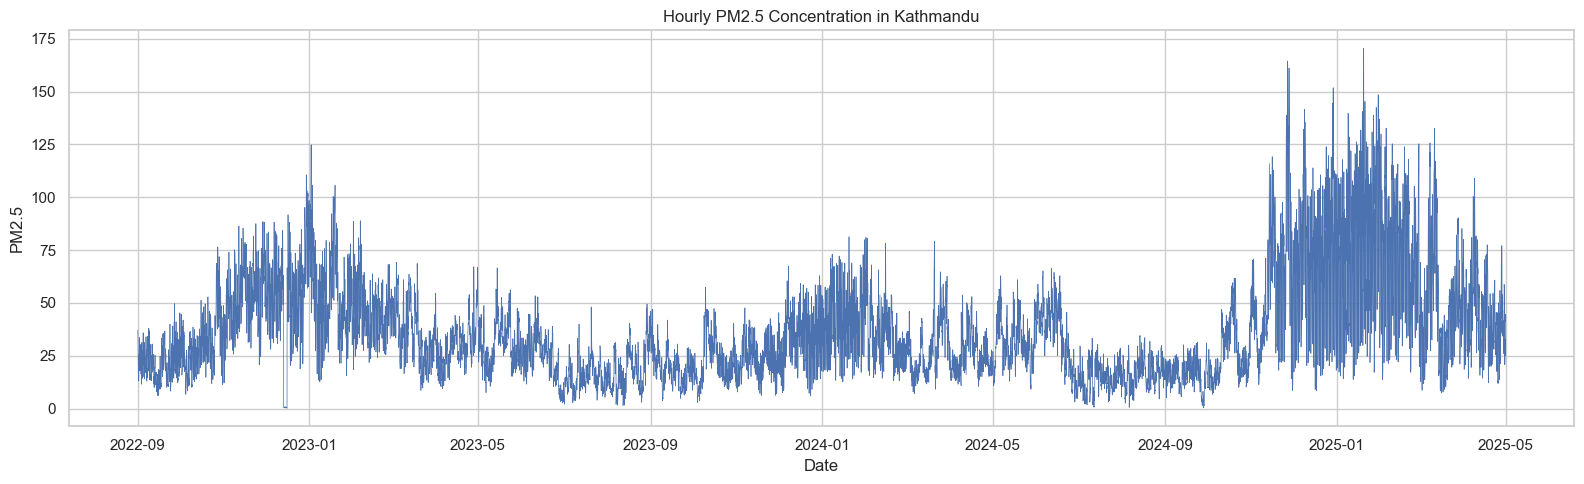

In [15]:
plt.figure(figsize=(16, 5))

plt.plot(
    hourly.index,
    hourly['pm25'],
    linewidth=0.5
)

plt.title(
    'Hourly PM2.5 Concentration in Kathmandu'
)

plt.xlabel('Date')
plt.ylabel('PM2.5')

plt.tight_layout()
plt.show()

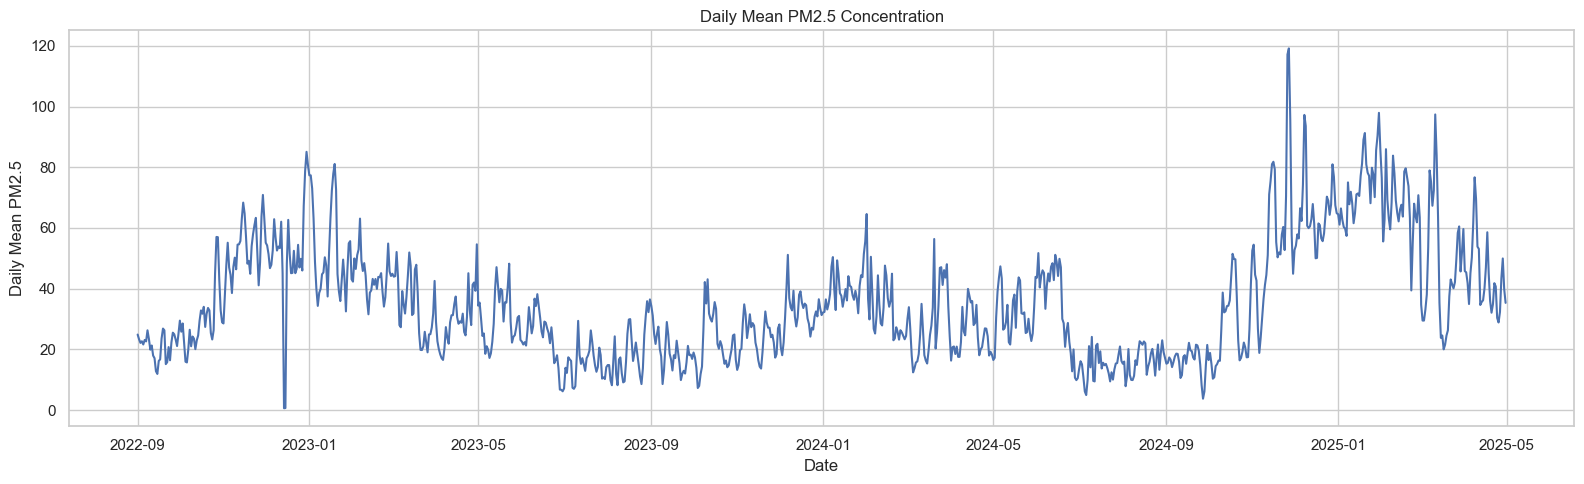

In [16]:
#Daily PM2.5 trend
plt.figure(figsize=(16, 5))

plt.plot(
    daily.index,
    daily['pm25_mean']
)

plt.title(
    'Daily Mean PM2.5 Concentration'
)

plt.xlabel('Date')
plt.ylabel('Daily Mean PM2.5')

plt.tight_layout()
plt.show()

In [17]:
#7-day and 30-day rolling means
daily['pm25_7d_mean'] = (
    daily['pm25_mean']
    .rolling(7)
    .mean()
)

daily['pm25_30d_mean'] = (
    daily['pm25_mean']
    .rolling(30)
    .mean()
)

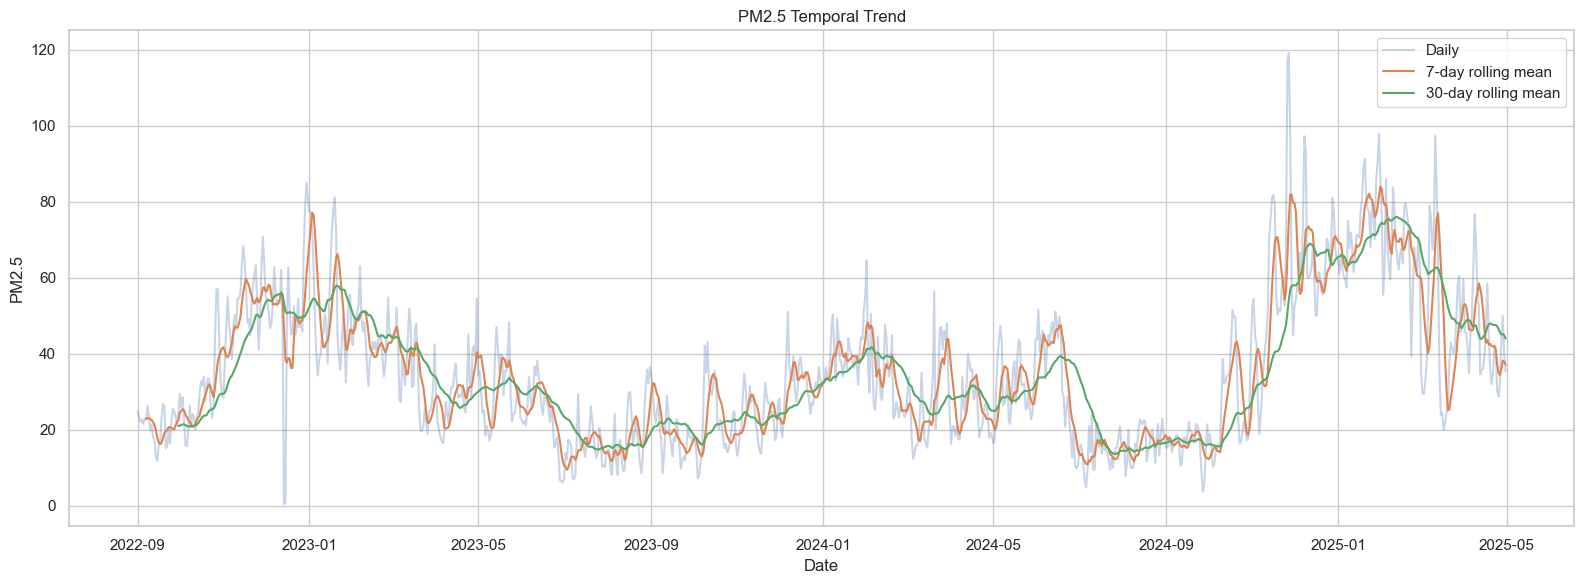

In [18]:
plt.figure(figsize=(16, 6))

plt.plot(
    daily.index,
    daily['pm25_mean'],
    alpha=0.3,
    label='Daily'
)

plt.plot(
    daily.index,
    daily['pm25_7d_mean'],
    label='7-day rolling mean'
)

plt.plot(
    daily.index,
    daily['pm25_30d_mean'],
    label='30-day rolling mean'
)

plt.title(
    'PM2.5 Temporal Trend'
)

plt.xlabel('Date')
plt.ylabel('PM2.5')

plt.legend()
plt.tight_layout()
plt.show()

## AQI analysis

In [19]:
daily['particle_aqi'].describe()

count    973.000000
mean     100.149024
std       35.509539
min        3.000000
25%       71.000000
50%       91.000000
75%      126.000000
max      196.000000
Name: particle_aqi, dtype: float64

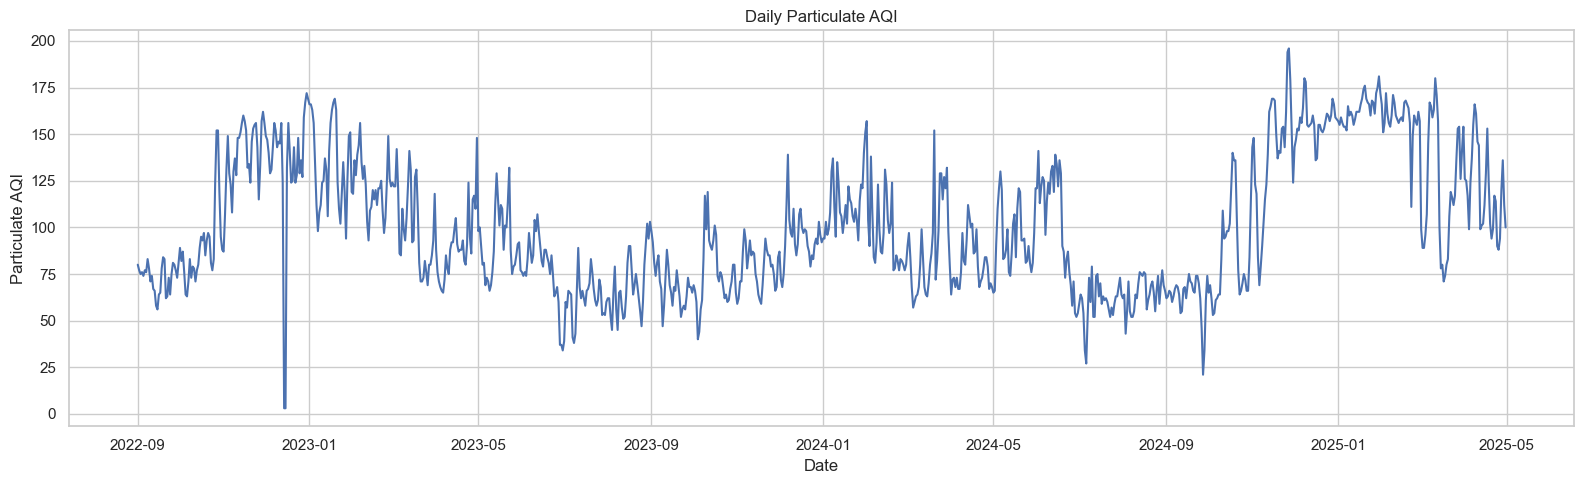

In [20]:
#aqi trend
plt.figure(figsize=(16, 5))

plt.plot(
    daily.index,
    daily['particle_aqi']
)

plt.title(
    'Daily Particulate AQI'
)

plt.xlabel('Date')
plt.ylabel('Particulate AQI')

plt.tight_layout()
plt.show()

In [21]:
#aqi categorical counts
aqi_counts = (
    daily['particle_aqi_category']
    .value_counts()
    .reindex(aqi_order)
)

aqi_counts

particle_aqi_category
Good                               21
Moderate                          555
Unhealthy for Sensitive Groups    252
Unhealthy                         145
Very Unhealthy                      0
Hazardous                           0
Name: count, dtype: int64

In [22]:
aqi_percentages = (
    aqi_counts
    / len(daily)
    * 100
)

aqi_percentages.round(2)

particle_aqi_category
Good                               2.16
Moderate                          57.04
Unhealthy for Sensitive Groups    25.90
Unhealthy                         14.90
Very Unhealthy                     0.00
Hazardous                          0.00
Name: count, dtype: float64

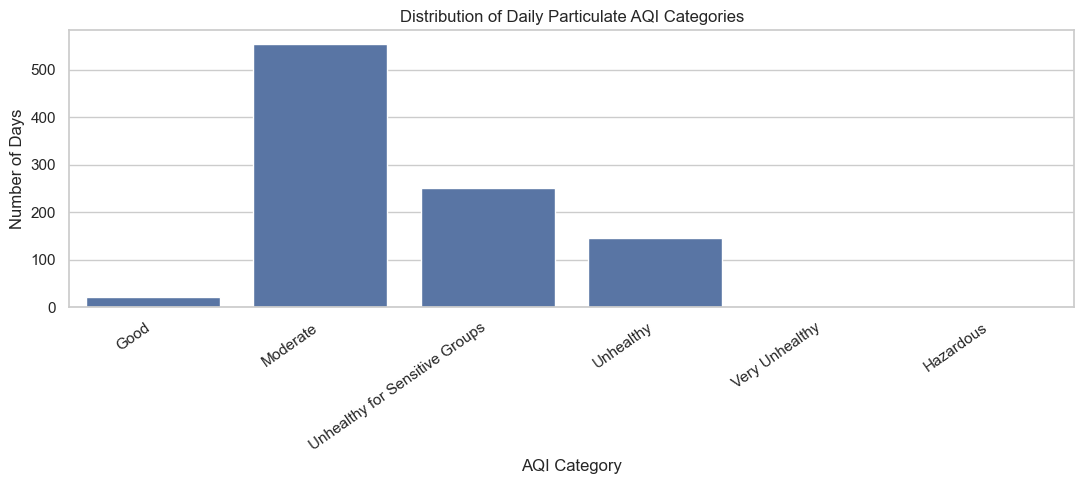

In [23]:
plt.figure(figsize=(11, 5))

sns.barplot(
    x=aqi_counts.index,
    y=aqi_counts.values
)

plt.xticks(
    rotation=35,
    ha='right'
)

plt.title(
    'Distribution of Daily Particulate AQI Categories'
)

plt.xlabel('AQI Category')
plt.ylabel('Number of Days')

plt.tight_layout()
plt.show()

## RQ1: Hourly patterns

In [24]:
hourly_pm25_pattern = (
    hourly
    .groupby('hour')['pm25']
    .agg([
        'mean',
        'median',
        'std',
        'count'
    ])
)

hourly_pm25_pattern

,mean,median,std,count
hour,,,,
0,43.534430,36.0,28.556127,973
1,41.454368,34.0,27.519761,973
2,39.498767,32.4,26.412615,973
3,37.707605,30.9,25.274461,973
4,36.138232,29.7,24.142018,973
5,35.758171,29.3,24.016966,973
6,38.218294,32.0,24.333896,973
7,40.478006,33.5,26.503810,973
8,37.139979,30.0,25.838245,973


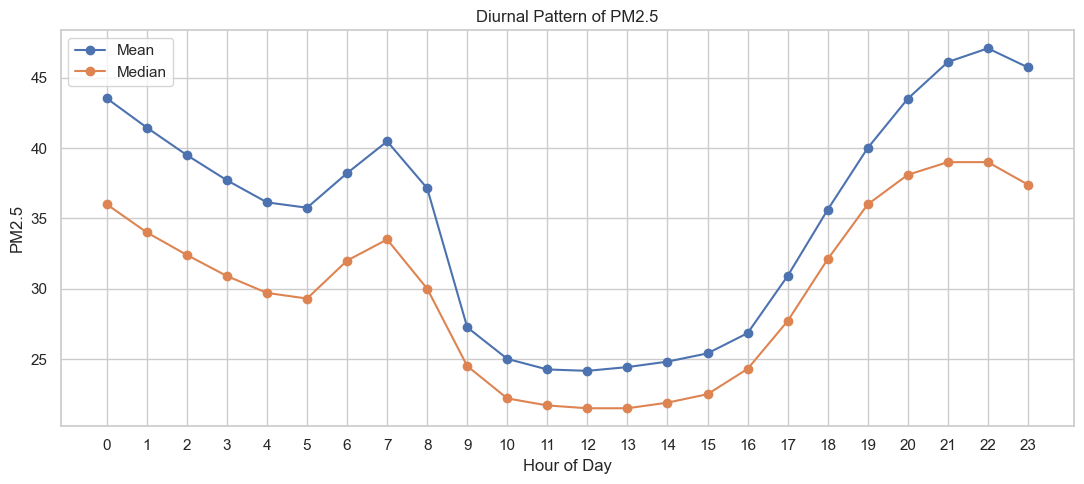

In [25]:
plt.figure(figsize=(11, 5))

plt.plot(
    hourly_pm25_pattern.index,
    hourly_pm25_pattern['mean'],
    marker='o',
    label='Mean'
)

plt.plot(
    hourly_pm25_pattern.index,
    hourly_pm25_pattern['median'],
    marker='o',
    label='Median'
)

plt.xticks(range(24))

plt.title(
    'Diurnal Pattern of PM2.5'
)

plt.xlabel('Hour of Day')
plt.ylabel('PM2.5')

plt.legend()
plt.tight_layout()
plt.show()

In [26]:
#All pollutants by hour
hourly_pollutant_pattern = (
    hourly
    .groupby('hour')[pollutants]
    .median()
)

hourly_pollutant_pattern

,pm25,pm10,no2,so2,co
hour,,,,,
0,36.0,51.7,22.6,7.3,818.0
1,34.0,48.8,18.6,6.9,743.0
2,32.4,46.6,15.8,6.8,672.0
3,30.9,44.6,14.0,6.7,643.0
4,29.7,42.8,13.1,6.5,626.0
5,29.3,42.3,13.1,6.3,631.0
6,32.0,46.2,11.9,6.3,599.0
7,33.5,48.9,9.3,6.3,522.0
8,30.0,45.2,6.4,6.1,442.0


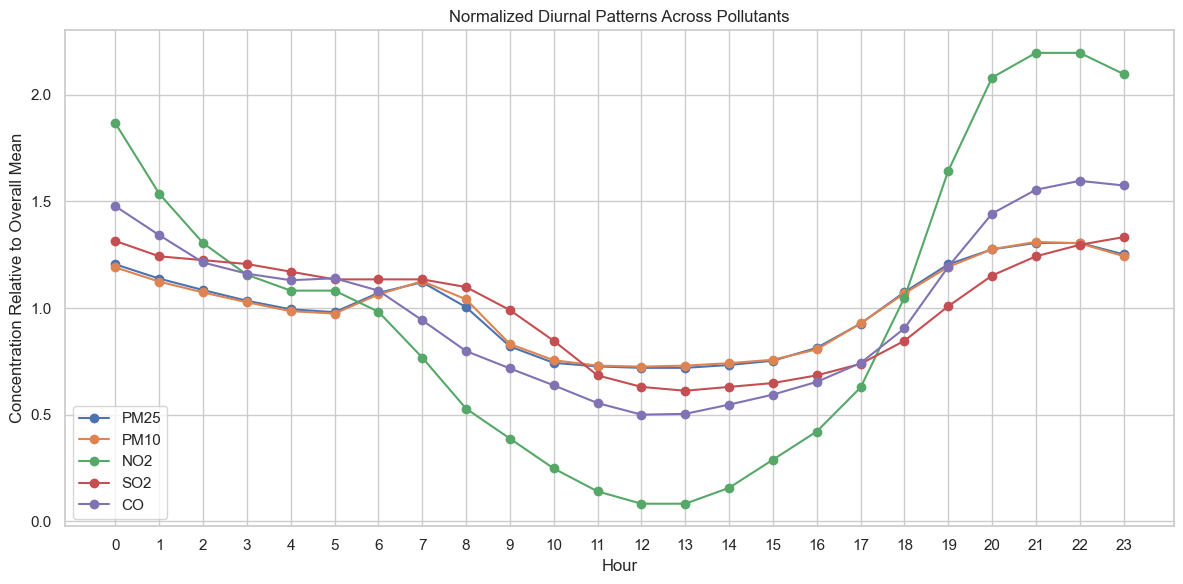

In [27]:
normalized_hourly = (
    hourly_pollutant_pattern
    / hourly_pollutant_pattern.mean()
)

plt.figure(figsize=(12, 6))

for pollutant in pollutants:

    plt.plot(
        normalized_hourly.index,
        normalized_hourly[pollutant],
        marker='o',
        label=pollutant.upper()
    )

plt.xticks(range(24))

plt.title(
    'Normalized Diurnal Patterns Across Pollutants'
)

plt.xlabel('Hour')
plt.ylabel(
    'Concentration Relative to Overall Mean'
)

plt.legend()
plt.tight_layout()
plt.show()

## Day-of-week and weekend patterns

In [28]:
dow_pm25 = (
    hourly
    .groupby('day_name', observed=False)['pm25']
    .agg([
        'mean',
        'median'
    ])
    .reindex(day_order)
)

dow_pm25

,mean,median
day_name,,
Monday,35.790887,30.25
Tuesday,35.787590,29.30
Wednesday,35.235192,27.65
Thursday,34.865378,28.15
Friday,34.698112,29.00
Saturday,34.037500,29.70
Sunday,34.903297,29.10


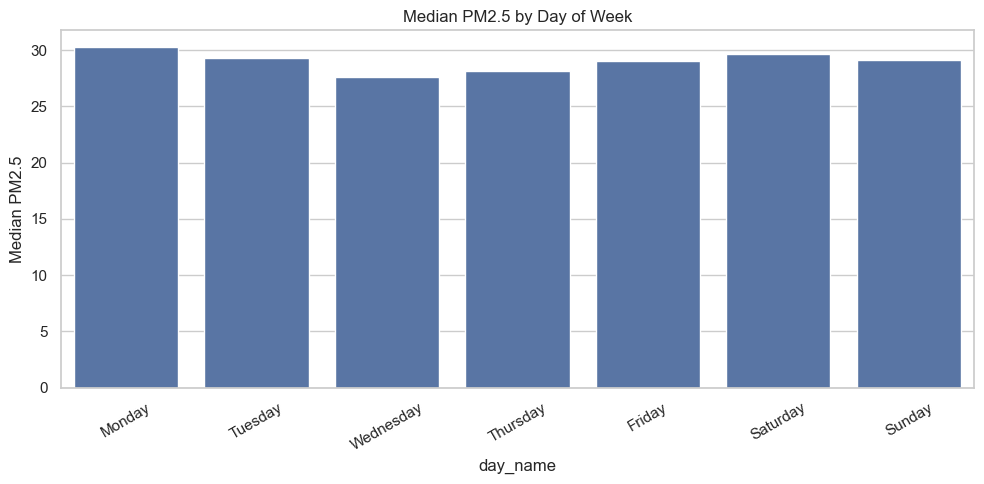

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=dow_pm25.index,
    y=dow_pm25['median']
)

plt.xticks(rotation=30)

plt.title(
    'Median PM2.5 by Day of Week'
)

plt.ylabel('Median PM2.5')

plt.tight_layout()
plt.show()

In [30]:
weekday_weekend = (
    hourly
    .groupby('day_type')['pm25']
    .agg([
        'count',
        'mean',
        'median',
        'std'
    ])
)

weekday_weekend

,count,mean,median,std
day_type,,,,
Weekday,16680,35.275432,28.9,23.551297
Weekend,6672,34.470399,29.3,22.478715


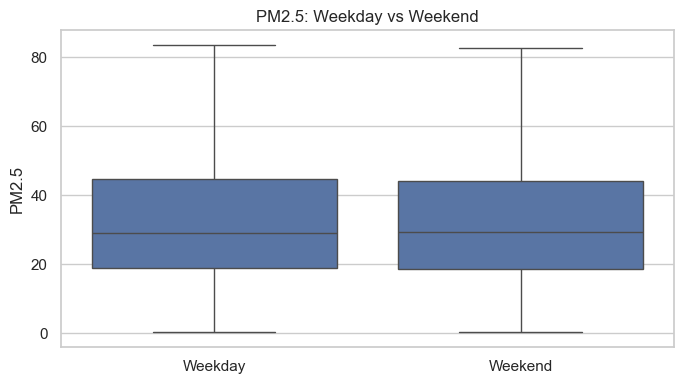

In [31]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=hourly,
    x='day_type',
    y='pm25',
    showfliers=False
)

plt.title(
    'PM2.5: Weekday vs Weekend'
)

plt.xlabel('')
plt.ylabel('PM2.5')

plt.tight_layout()
plt.show()

In [32]:
#Monthly patterns
monthly_pm25 = (
    hourly
    .groupby('month')['pm25']
    .agg([
        'mean',
        'median',
        'std',
        'count'
    ])
)

monthly_pm25

,mean,median,std,count
month,,,,
1,55.348387,48.20,29.158043,2232
2,48.158775,41.60,24.775296,2040
3,36.875762,33.25,20.444201,2232
4,32.946806,29.50,15.628317,2160
5,30.987298,30.00,10.707495,1488
6,29.503264,28.80,13.912088,1440
7,14.953024,14.40,6.894502,1488
8,17.642540,16.60,8.540674,1488
9,18.784444,18.30,7.428909,2160


In [33]:
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

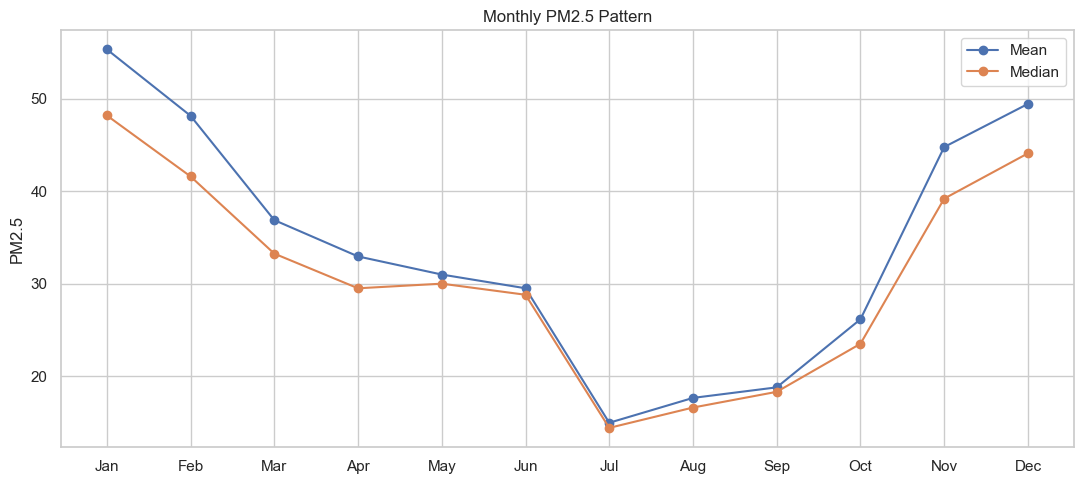

In [34]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_pm25.index,
    monthly_pm25['mean'],
    marker='o',
    label='Mean'
)

plt.plot(
    monthly_pm25.index,
    monthly_pm25['median'],
    marker='o',
    label='Median'
)

plt.xticks(
    range(1, 13),
    month_labels
)

plt.title(
    'Monthly PM2.5 Pattern'
)

plt.ylabel('PM2.5')

plt.legend()
plt.tight_layout()
plt.show()